# Лабораторна робота №1
## Варіант 2. Авторегресивна генерація тексту BBC

### 1. Постановка задачі
Для авторегресивної генерації використовуємо корпус BBC News із довшими зв'язними статтями. Вони дають послідовний контекст для прогнозування наступного токена власною моделлю з `TransformerDecoderLayer`. Категорія статті — лише metadata для EDA та стратифікації: вона не додається до тексту, входів або цілей.

Послідовність: документи → split → train vocabulary → вікна → baseline → validation → tuning → вибір checkpoint → фінальний test. Навчальні комірки запускаються вручну засобами Jupyter.


### 2. Налаштування експерименту

Шляхи визначаємо один раз від кореня репозиторію. Гіперпараметри baseline та бюджет навчання зібрано нижче; `GRID_CONFIGS` імпортується зі спільного runner, тому таблиця конфігурацій відповідає фактичному grid.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = next((p for p in (cwd, *cwd.parents)
                  if (p / "labs/lab01_transformer/src").is_dir()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Відкрийте notebook із репозиторію або каталогу Lab 1")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [2]:
from functools import partial
import pandas as pd
import torch
from IPython.display import display
from labs.lab01_transformer.src.common.reproducibility import seed_everything, device_info
from labs.lab01_transformer.src.common.text import Vocabulary, tokenize, BOS
from labs.lab01_transformer.src.common.checkpoint import load_checkpoint
from labs.lab01_transformer.src.common.experiments import GRID_CONFIGS, run_grid, select_checkpoint
from labs.lab01_transformer.src.common.inspection import (
    read_training_results, summarize_checkpoint,
)
from labs.lab01_transformer.src.common.visualization import (
    plot_positional_encoding, plot_history, plot_comparison,
    plot_causal_mask,
)
from labs.lab01_transformer.src.generation.data import (
    inspect_corpus, clean_corpus, split_corpus, create_loaders, corpus_metadata,
)
from labs.lab01_transformer.src.generation.corpus_inspection import (
    summarize_corpus, summarize_corpus_splits, plot_corpus_overview,
)
from labs.lab01_transformer.src.generation.model import CausalLanguageModel, causal_mask
from labs.lab01_transformer.src.generation.inspection import (
    inspect_autoregressive_batch, inspect_generation_pipeline, verify_causal_invariance,
)
from labs.lab01_transformer.src.generation.train import fit_language_model
from labs.lab01_transformer.src.generation.evaluate import evaluate_final_generation, evaluate_continuations

In [3]:
SEED = 42
BATCH_SIZE = 32
MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 1e-3
VOCAB_CONFIG = dict(max_size=12000, min_frequency=2)
WINDOW_LENGTH = 64
WINDOW_STRIDE = 64
MODEL_CONFIG = dict(d_model=64, nhead=2, num_layers=1,
                    dim_feedforward=256, dropout=.1)
CONTINUATION_CONFIG = dict(context_length=32, continuation_length=32, sample_size=64)

In [4]:
LAB_ROOT = REPO_ROOT / "labs" / "lab01_transformer"
DATA_PATH = LAB_ROOT / "data" / "raw" / "bbc-text.csv"
OUTPUT_DIR = LAB_ROOT / "outputs" / "generation" / "bbc" / "early_stopping"
BASELINE_DIR = OUTPUT_DIR / "baseline"
BASELINE_CHECKPOINT = BASELINE_DIR / "checkpoints" / "best.pt"
EXPERIMENTS_DIR = OUTPUT_DIR / "experiments"
FIGURES_DIR = OUTPUT_DIR / "figures"

Фіксуємо seed Python, NumPy та PyTorch. CUDA обирається автоматично, CPU залишається доступним; тотожність між різним обладнанням не гарантується. Компактний baseline розрахований на локальне навчання з 4 GB VRAM. Нові запуски використовують `generation/bbc/early_stopping/`, не змішуючись зі старим протоколом; повторний запуск у цьому каталозі перезаписує відповідні артефакти.

In [5]:
seed_everything(SEED)
DEVICE = device_info()
display(pd.DataFrame(GRID_CONFIGS, columns=["d_model", "nhead"]))

PyTorch: 2.14.0+cu130; device: cuda
NVIDIA GeForce RTX 3050 Laptop GPU


,d_model,nhead
0,64,2
1,64,4
2,128,2
3,128,4


### 3. Завантаження та аналіз BBC

Перевіряємо UTF-8 і точну схему `category,text`; некоректні рядки CSV спричиняють помилку. Показуємо пропуски, точні дублікати, категорії та довжини. Порожні тексти вилучаємо; серед точних повторів зберігаємо перший запис. Не нормалізуємо текст для dedup і не виконуємо семантичне очищення. Raw CSV залишається незмінним.


In [6]:
raw_data = inspect_corpus(DATA_PATH)
data = clean_corpus(raw_data)
corpus_counts, corpus_lengths, category_counts = summarize_corpus(raw_data, data)
display(corpus_counts, corpus_lengths, category_counts)
display(data.head())

raw_documents         2225
duplicate_texts         99
missing_texts            0
missing_categories       0
clean_documents       2126
dtype: int64

,words,tokens
count,2225.000000,2225.000000
mean,390.295281,424.797753
std,241.753128,260.055128
min,90.000000,97.000000
50%,337.000000,369.000000
90%,629.200000,674.600000
95%,736.400000,802.600000
99%,1018.040000,1107.320000
max,4492.000000,4811.000000


category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

,category,text,document_id
0,tech,tv future in the hands of viewers with home th...,0d0334fa3cad64b8e2e70b5b8a904cf6296022a4a94e6b...
1,business,worldcom boss left books alone former worldc...,a1340885771c8a7f1c94836834307285ac9a6bfa331cbd...
2,sport,tigers wary of farrell gamble leicester say ...,13411aea67c67dc9fea1a292dd2d5586d58bad8759c349...
3,sport,yeading face newcastle in fa cup premiership s...,7c6f454700e8a24677d8ded8440fae51e45d5c9226d025...
4,entertainment,ocean s twelve raids box office ocean s twelve...,41dec65a1e7fa1cc02c870b706dbbeed8f5638d7105913...


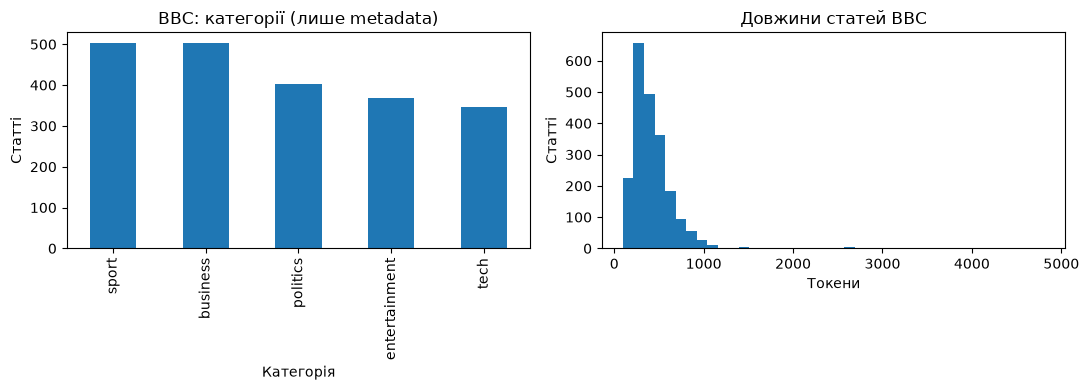

In [7]:
corpus_figure = plot_corpus_overview(data, FIGURES_DIR / "corpus_lengths.png")
display(corpus_figure)

**Інтерпретація.** Raw BBC містить 2225 статей та 99 точних повторів; після dedup — 2126. Медіана довжини — 369 regex-токенів, 95-й перцентиль — приблизно 803. Статті потребують кількох компактних вікон, а не обрізання до одного входу. Категорії описують склад корпусу, але не є цілями моделі.

### 4. Розбиття документів та словник

Стратифікований за категорією split 70/15/15, seed=42, виконуємо **до вікон**: 1488 train, 319 validation, 319 test. SHA-256 точного тексту є document ID; перевіряємо відсутність спільних ID та текстів між split.

Regex lowercase виділяє слова й пунктуацію. Словник будуємо **тільки на train**, min_frequency=2, максимум 12000 разом зі спеціальними токенами PAD=0, UNK=1, BOS=2, EOS=3. Train UNK становить 2,81% проти 5,17% за ліміту 8000; 12000 обмежує розмір вихідного шару. Невідомі слова validation/test стають UNK, словник не доповнюється.

Вікно 64 і stride 64 дають контекст для локальних залежностей без важкого attention цілої статті та без повторення цілей. Це компактний старт для 4 GB VRAM; фактична пам'ять залежить від конфігурації та batch size. Validation/test не визначають параметри preprocessing.


In [8]:
splits = split_corpus(data, seed=SEED)
vocabulary = Vocabulary.build(splits["train"].text, **VOCAB_CONFIG)
max_len = WINDOW_LENGTH
DATASET_METADATA = corpus_metadata(DATA_PATH, vocabulary, VOCAB_CONFIG, max_len, WINDOW_STRIDE, SEED)
split_summary = summarize_corpus_splits(splits, vocabulary, max_len)
display(split_summary, pd.Series({"vocabulary_size": len(vocabulary), **DATASET_METADATA}))

,documents,tokens,windows,unk_percent
split,,,,
train,1488,635644,10669,2.813997
validation,319,132119,2230,4.394523
test,319,135638,2284,4.478096


vocabulary_size                                                  12000
dataset                                                       bbc-news
source_sha256        fdaee0f7451cd8db2709d00e992886fe1c387ee332b8c7...
tokenizer                                           lowercase_regex_v1
vocabulary_config              {'max_size': 12000, 'min_frequency': 2}
vocabulary_sha256    3a74fd29c4931e645b7ac8eda96c8d58e99ce3b7106908...
max_len                                                             64
stride                                                              64
split_seed                                                          42
split_policy            exact-text-first; category-stratified 70/15/15
dtype: object

In [9]:
sample_text = splits["train"].text.iloc[0]
display(pd.DataFrame({"token": tokenize(sample_text), "id": vocabulary.encode(sample_text)}).head(16))

,token,id
0,three,115
1,djs,5185
2,replace,1570
3,peel,2703
4,radio,293
5,show,164
6,the,4
7,late,687
8,john,439
9,peel,2703


**Інтерпретація.** Таблиця містить кількість документів, токенів, вікон та частку UNK кожного split. Кількість вікон рахується без навчання. Test тут використовується лише для перевірки структури даних; model selection отримує тільки train/validation. Таблиця token → id показує фактичний вихід tokenizer.

#### Авторегресивні вікна
Додаємо BOS і EOS, а потім формуємо `input=t₀…tₙ₋₁`, `target=t₁…tₙ`. Наприклад, для `[BOS, hello, world, EOS]` вхід — `[BOS, hello, world]`, ціль — `[hello, world, EOS]`. Це лише пояснення shift; навчальні послідовності походять із реального CSV.

Документи розділяються **до** створення вікон. Вікна не перетинають меж документів або split; кожна ціль трапляється один раз. Сусідні вікна одного документа мають один спільний граничний токен для правильного shift. Останнє вікно доповнюється PAD праворуч; PAD ігнорується в loss.

In [10]:
training_splits = {name: splits[name] for name in ("train", "validation")}
make_loaders = partial(create_loaders, training_splits, vocabulary, max_len, batch_size=BATCH_SIZE, stride=WINDOW_STRIDE)
loaders = make_loaders(seed=SEED)
input_ids, targets = next(iter(loaders["validation"]))
shift_preview = inspect_autoregressive_batch(input_ids, targets, vocabulary)
display(shift_preview)

,input,target
0,<bos>,smith
1,smith,keen
2,keen,on
3,on,home
4,home,series
5,series,return
6,return,scotland
7,scotland,manager
8,manager,walter
9,walter,smith


### 5. Transformer Decoder

`tokens → ids → shifted input/target → embedding → PE → causal Decoder → vocabulary logits`.

Вхід має форму `[B,L]`, проміжні представлення — `[B,L,d_model]`, logits — `[B,L,vocab_size]`. Cross-attention memory — один сталий нульовий вектор, незалежний від тексту; він не передає майбутні токени. Інспекція нижче показує реальні tensors і порівнює результат зі звичайним forward. Архітектура залишається власною композицією TransformerDecoderLayer.

In [11]:
model_config = dict(MODEL_CONFIG, vocab_size=len(vocabulary), max_len=max_len)
model = CausalLanguageModel(**model_config).to(DEVICE)
print(model)
shape_summary = inspect_generation_pipeline(model, input_ids[:2])
display(shape_summary)

CausalLanguageModel(
  (embedding): Embedding(12000, 64, padding_idx=0)
  (position): PositionalEncoding()
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0): TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm3): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dr

,shape,dtype
stage,,
input_ids,"(2, 64)",torch.int64
embedding,"(2, 64, 64)",torch.float32
positional_encoding,"(2, 64, 64)",torch.float32
memory,"(2, 1, 64)",torch.float32
causal_mask,"(64, 64)",torch.bool
decoder_output,"(2, 64, 64)",torch.float32
logits,"(2, 64, 12000)",torch.float32


### 6. Позиційне кодування

Self-attention без позиційної інформації не визначає порядок токенів. До embedding додаємо фіксовані синусоїди:

$$PE(pos,2i)=\sin(pos/10000^{2i/d_{model}}),\quad PE(pos,2i+1)=\cos(pos/10000^{2i/d_{model}}).$$

На тепловій карті різні виміри мають різні частоти. Buffer переноситься разом із моделлю між CPU та CUDA; параметри PE не навчаються.

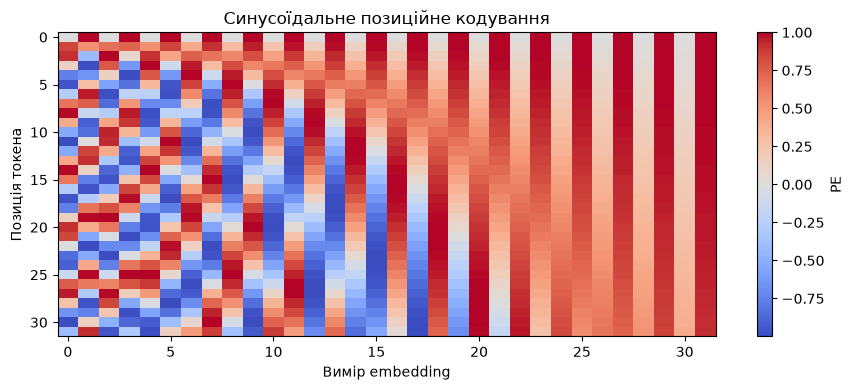

In [12]:
position_figure = plot_positional_encoding(model.position, FIGURES_DIR / "positional_encoding.png")
display(position_figure)

### 7. Causal mask і перевірка витоку
`True` над головною діагоналлю означає заборонений attention. Одного `tgt_mask` було б недостатньо, якби memory містила майбутні входи. Окрім аналізу memory, порівнюємо logits однакового prefix при зміні suffix у режимі eval (без dropout).

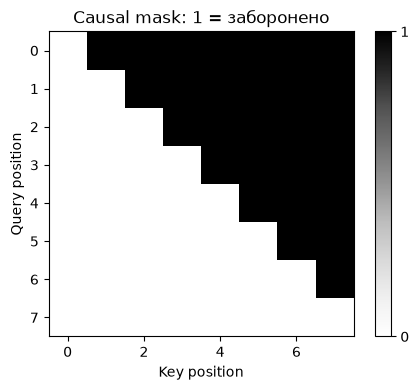

In [13]:
mask_figure = plot_causal_mask(causal_mask(8), FIGURES_DIR / "causal_mask.png")
display(mask_figure)

In [14]:
first = torch.tensor([[BOS, 4, 5, 6, 7, 8]])
changed_suffix = torch.tensor([[BOS, 4, 5, 9, 10, 11]])
causality_report = verify_causal_invariance(model, first, changed_suffix, prefix_length=3)
display(causality_report)

,max_absolute_difference,passed
check,,
changed_suffix,0.000000e+00,True
deleted_suffix,9.536743e-07,True
padded_suffix,0.000000e+00,True


**Інтерпретація.** Структурний приклад вище не є навчальним корпусом. Prefix однаковий, suffix змінено. Перевірка також видаляє suffix і замінює його на PAD; prefix logits мають залишатися незмінними в межах atol=1e-6, rtol=1e-5. Невиконання інваріанта спричиняє помилку.

### 8. Baseline та early stopping

Baseline перевіряє навчання однієї компактної моделі. CrossEntropyLoss ігнорує PAD: сумарний negative log-likelihood ділиться на кількість непорожніх цільових токенів. `perplexity = exp(loss)`; при loss ≥709 повертаємо infinity замість переповнення. Навчання припиняється з помилкою при нечислових або нескінченних validation-метриках.

`MAX_EPOCHS=30` задає верхню межу. Якщо **validation token cross-entropy** не зменшується протягом `PATIENCE=5` послідовних епох, навчання достроково зупиняється. Строге зменшення скидає лічильник; рівність не є покращенням. Використовується checkpoint із найменшим validation loss. Perplexity монотонно залежить від loss, тому обидва критерії узгоджені; BLEU/ROUGE-L не використовуємо для per-epoch stopping.

> **Ручний запуск.** Ця комірка запускає навчання моделі та може виконуватися кілька хвилин. Спочатку виконайте підготовку даних і перевірку причинності. Test не бере участі в early stopping.

In [15]:
seed_everything(SEED)
model = CausalLanguageModel(**model_config)
loaders = make_loaders(seed=SEED)
baseline_result = fit_language_model(
    model, loaders, vocabulary, DEVICE, BASELINE_DIR,
    max_epochs=MAX_EPOCHS, patience=PATIENCE, learning_rate=LEARNING_RATE, seed=SEED,
    dataset_metadata=DATASET_METADATA,
)

{'epoch': 1, 'train_loss': 6.890577979903988, 'validation_loss': 6.286426906481712, 'validation_perplexity': 537.2303214081786}
{'epoch': 2, 'train_loss': 6.1971153260762195, 'validation_loss': 5.994336928529765, 'validation_perplexity': 401.15060426477464}
{'epoch': 3, 'train_loss': 5.937805116387283, 'validation_loss': 5.855777396044517, 'validation_perplexity': 349.246297238804}
{'epoch': 4, 'train_loss': 5.771709306466566, 'validation_loss': 5.776824159878113, 'validation_perplexity': 322.7326139746473}
{'epoch': 5, 'train_loss': 5.64667816640135, 'validation_loss': 5.72796782297424, 'validation_perplexity': 307.34405579206435}
{'epoch': 6, 'train_loss': 5.550119431074526, 'validation_loss': 5.698152876841427, 'validation_perplexity': 298.315865603077}
{'epoch': 7, 'train_loss': 5.472095823856457, 'validation_loss': 5.681478742057604, 'validation_perplexity': 293.3829470163109}
{'epoch': 8, 'train_loss': 5.408223675312524, 'validation_loss': 5.672729471909733, 'validation_perplexit

#### Збережені результати baseline

Читаємо історію й summary з диска: best epoch може не збігатися з останньою епохою. Після перезапуску kernel повторне навчання не потрібне, якщо ці артефакти вже існують. Криві містять лише фактично виконані епохи.

,Значення
best_epoch,12
epochs_trained,17
stopped_early,True
stop_reason,patience
seconds,81.966239
parameters,1614752
best_validation_metric.loss,5.660488
best_validation_metric.perplexity,287.288799
training_config.max_epochs,30
training_config.patience,5


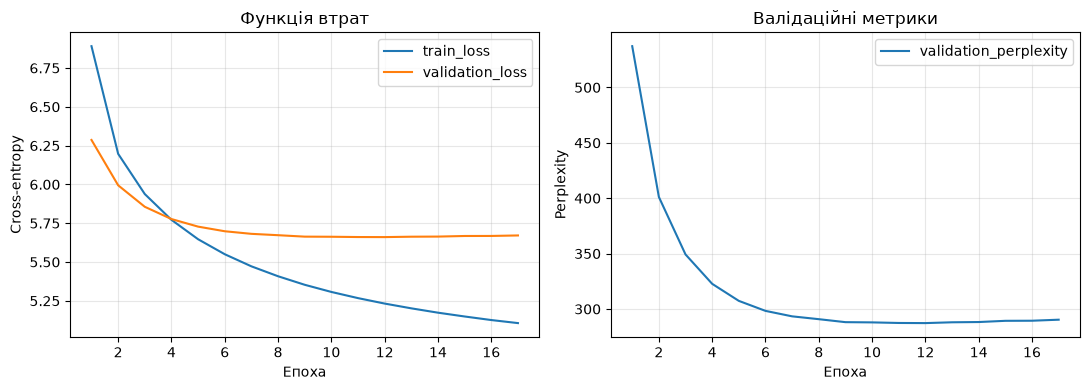

In [16]:
baseline_history, training_summary = read_training_results(BASELINE_DIR)
display(training_summary)
history_figure = plot_history(baseline_history, "generation", FIGURES_DIR / "history.png")
display(history_figure)

**Інтерпретація.** Вкажіть best epoch і причину завершення. Зіставте train/validation loss та validation-метрики; розходження кривих може свідчити про перенавчання. Числові висновки формулюються за фактичними результатами.

### 9. Авторегресивне продовження

Завантажуємо BBC baseline з перевіркою dataset/preprocessing metadata. Беремо три реальні validation-статті: перші 32 токени — context, наступні 32 — reference continuation. Greedy loop бачить тільки context і власні попередні токени, зупиняється на EOS або після 32 нових токенів; довгий context обмежується останніми max_len токенами. Таблиця показує context/reference/generated одного й того самого документа; train-приклади тут не використовуються.


In [17]:
baseline_model, baseline_vocabulary, baseline_metadata = load_checkpoint(
    BASELINE_CHECKPOINT, DEVICE, expected_dataset_metadata=DATASET_METADATA,
)

> **Ручний запуск.** Комірка генерує коротке продовження після відновлення baseline checkpoint. Ліміт нових токенів задано в CONTINUATION_CONFIG.

In [18]:
demo_config = {**CONTINUATION_CONFIG, "sample_size": 3}
_, validation_examples = evaluate_continuations(
    baseline_model, baseline_vocabulary, splits["validation"].text, seed=SEED, **demo_config,
)
with pd.option_context("display.max_colwidth", None):
    display(validation_examples)

,context,reference,generated
0,china continues breakneck growth china s economy has expanded by a breakneck 9 . 5 % during 2004 faster than predicted and well above 2003 s 9 . 1 % . the,news may mean more limits on investment and lending as beijing tries to take the economy off the boil . china has sucked in raw materials and energy to feed its expansion,<unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> .
1,royal couple watch nation s mood prince charles and camilla parker bowles are awaiting the nation s reaction after announcing they are to be married on 8 april . mrs parker bowles,will take the title hrh duchess of cornwall after a civil ceremony to be held at windsor castle . a daily telegraph poll of 1 313 people suggests two - thirds of,. the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the
2,holmes wins 2004 top tv moment sprinter kelly holmes olympic victory has been named the top television moment of 2004 in a bbc poll . holmes 800m gold medal victory beat favourite,moments from drama comedy and factual programmes as voted by television viewers . natasha kaplinsky s strictly come dancing win was top entertainment moment and a little britain breast feeding sketch won,to the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the


### 10. Підбір d_model і nhead

Порівнюємо 64/2, 64/4, 128/2 та 128/4. `d_model` задає розмір представлення токена, `nhead` — кількість attention heads; подільність перевіряє конструктор. Інші параметри, split, seed, порядок batch та early-stopping policy однакові. Кількість фактично виконаних епох може відрізнятися: кожна модель зупиняється за власною validation-кривою. Вибір — за validation cross-entropy (мінімум).

Якщо поки досліджуєте лише baseline, пропустіть комірки grid і comparison. Остаточне виконання лабораторної включає порівняння обов'язкових гіперпараметрів.

> **Ручний запуск.** Буде навчено чотири моделі, кожну максимум `MAX_EPOCHS` епох із `PATIENCE` непокращень. Цей етап довший за baseline і не оцінює test.

In [19]:
grid_results = run_grid(
    CausalLanguageModel, model_config, make_loaders, vocabulary, DEVICE,
    EXPERIMENTS_DIR, "generation",
    max_epochs=MAX_EPOCHS, patience=PATIENCE, learning_rate=LEARNING_RATE, seed=SEED,
    dataset_metadata=DATASET_METADATA,
)
display(grid_results)

{'epoch': 1, 'train_loss': 6.890577979903988, 'validation_loss': 6.286426906481712, 'validation_perplexity': 537.2303214081786}
{'epoch': 2, 'train_loss': 6.1971153260762195, 'validation_loss': 5.994336928529765, 'validation_perplexity': 401.15060426477464}
{'epoch': 3, 'train_loss': 5.937805116387283, 'validation_loss': 5.855777396044517, 'validation_perplexity': 349.246297238804}
{'epoch': 4, 'train_loss': 5.771709306466566, 'validation_loss': 5.776824159878113, 'validation_perplexity': 322.7326139746473}
{'epoch': 5, 'train_loss': 5.64667816640135, 'validation_loss': 5.72796782297424, 'validation_perplexity': 307.34405579206435}
{'epoch': 6, 'train_loss': 5.550119431074526, 'validation_loss': 5.698152876841427, 'validation_perplexity': 298.315865603077}
{'epoch': 7, 'train_loss': 5.472095823856457, 'validation_loss': 5.681478742057604, 'validation_perplexity': 293.3829470163109}
{'epoch': 8, 'train_loss': 5.408223675312524, 'validation_loss': 5.672729471909733, 'validation_perplexit

,d_model,nhead,validation_loss,validation_perplexity,best_epoch,epochs_trained,stopped_early,parameters,seconds,checkpoint
0,64,2,5.660488,287.288799,12,17,True,1614752,84.040531,d64_h2\checkpoints\best.pt
1,64,4,5.652013,284.864254,12,17,True,1614752,81.974044,d64_h4\checkpoints\best.pt
2,128,2,5.631608,279.110503,7,12,True,3282784,75.589802,d128_h2\checkpoints\best.pt
3,128,4,5.633834,279.732651,7,12,True,3282784,78.073138,d128_h4\checkpoints\best.pt


#### Порівняння validation-результатів

Таблицю можна відкрити й після перезапуску kernel. Порівнюйте найкращі validation-метрики разом із best_epoch, фактичною кількістю епох, кількістю параметрів та часом. Якщо grid поки пропущено, пропустіть і цей графік.

,d_model,nhead,validation_loss,validation_perplexity,best_epoch,epochs_trained,stopped_early,parameters,seconds,checkpoint
0,64,2,5.660488,287.288799,12,17,True,1614752,84.040531,d64_h2\checkpoints\best.pt
1,64,4,5.652013,284.864254,12,17,True,1614752,81.974044,d64_h4\checkpoints\best.pt
2,128,2,5.631608,279.110503,7,12,True,3282784,75.589802,d128_h2\checkpoints\best.pt
3,128,4,5.633834,279.732651,7,12,True,3282784,78.073138,d128_h4\checkpoints\best.pt


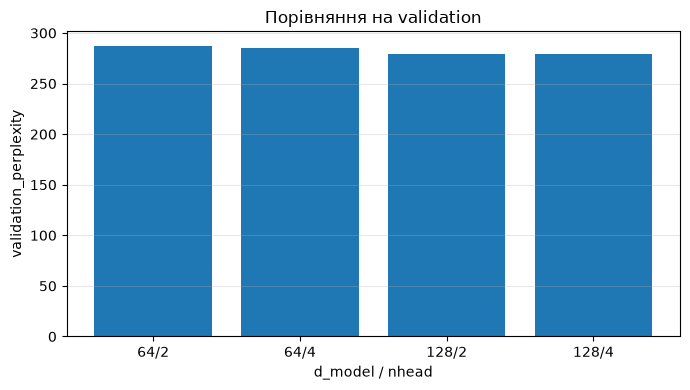

In [20]:
grid_results = pd.read_csv(EXPERIMENTS_DIR / "comparison.csv")
display(grid_results)
comparison_figure = plot_comparison(grid_results, "validation_perplexity",
                                    FIGURES_DIR / "comparison.png")
display(comparison_figure)

### 11. Вибір і відновлення моделі

Порівнюємо baseline і виконані grid-експерименти за мінімальним validation loss. Baseline не є автоматичним переможцем. Якщо grid пропущено, залишається baseline. Завантажуємо збережені ваги, словник і конфігурацію найкращої validation-епохи — вони можуть відрізнятися від стану моделі в останній епосі.

Ця комірка потребує збереженого baseline або grid у поточному `OUTPUT_DIR`. Після перезапуску kernel достатньо повторити підготовку даних і цю комірку; повторне навчання не потрібне.

In [21]:
selected_checkpoint = select_checkpoint(
    BASELINE_CHECKPOINT, EXPERIMENTS_DIR, "generation", expected_dataset_metadata=DATASET_METADATA,
)
selected_model, saved_vocabulary, checkpoint_metadata = load_checkpoint(
    selected_checkpoint, DEVICE, expected_dataset_metadata=DATASET_METADATA,
)
display(summarize_checkpoint(checkpoint_metadata), checkpoint_metadata["dataset_metadata"])
print(selected_checkpoint)

,Обрана модель
model.vocab_size,12000.000000
model.max_len,64.000000
model.d_model,128.000000
model.nhead,2.000000
model.num_layers,1.000000
model.dim_feedforward,256.000000
model.dropout,0.100000
best_epoch,7.000000
validation.loss,5.631608
validation.perplexity,279.110503


{'dataset': 'bbc-news',
 'source_sha256': 'fdaee0f7451cd8db2709d00e992886fe1c387ee332b8c7b7c1554ed3d3e3382e',
 'tokenizer': 'lowercase_regex_v1',
 'vocabulary_config': {'max_size': 12000, 'min_frequency': 2},
 'vocabulary_sha256': '3a74fd29c4931e645b7ac8eda96c8d58e99ce3b71069083fad77acdbc3443121',
 'max_len': 64,
 'stride': 64,
 'split_seed': 42,
 'split_policy': 'exact-text-first; category-stratified 70/15/15'}

C:\Users\Eclipse\PycharmProjects\neural-network-technologies-and-systems\labs\lab01_transformer\outputs\generation\bbc\early_stopping\experiments\d128_h2\checkpoints\best.pt


### 12. Фінальне оцінювання на test-вибірці

Perplexity оцінює всі test-вікна з teacher forcing та causal mask. Для BLEU-4 і ROUGE-L беремо до 64 реальних test-документів із ≥64 токенами, seed=42: перші 32 — контекст, наступні 32 — еталон. Greedy continuation обмежене 32 новими токенами; ранній EOS не доповнюється штучними словами.

BLEU — corpus BLEU-4 із NLTK smoothing method1, ROUGE-L — середнє token-level LCS F1 без stemming; обидві шкали 0–1. Еталони залишаються реальними словами, без заміни OOV на UNK. Низький збіг із єдиним еталоном не доводить беззмістовність усіх альтернативних продовжень. Це відтворювана підвибірка held-out статей BBC; кожен еталон є справжнім продовженням відповідного контексту.

> **Ручний запуск. Важливо:** цю комірку слід виконувати лише один раз після завершення tuning та відновлення обраної за validation моделі. Test не використовується для її налаштування. Оцінювання включає всі test-вікна та до 64 авторегресивних продовжень.

In [22]:
test_metrics, generation_samples = evaluate_final_generation(
    selected_model, saved_vocabulary, splits["test"], DEVICE, OUTPUT_DIR,
    batch_size=BATCH_SIZE, seed=SEED, **CONTINUATION_CONFIG,
)
display(pd.Series(test_metrics, name="Test"))
with pd.option_context("display.max_colwidth", None):
    display(generation_samples.head(3))

loss                     5.623352
perplexity             276.815826
bleu                     0.004911
rouge_l                  0.106445
examples                       64
eligible_documents            319
context_length                 32
continuation_length            32
decoding                   greedy
seed                           42
Name: Test, dtype: object

,context,reference,generated
0,burren awarded egyptian contracts british energy firm burren energy has been awarded two potentially lucrative oil exploration contracts in egypt . the company successfully bid for the two contracts granted by government,owned oil firms covering onshore and offshore areas in the gulf of suez . burren energy already has a presence in egypt having been awarded an exploration contract last year . the,s <unk> <unk> <unk> <unk> <unk> <unk> . the <unk> . the <unk> . the <unk> . the <unk> <unk> <unk> <unk> <unk> . the world s <unk> . the world s
1,worldcom director admits lying the former chief financial officer at us telecoms firm worldcom has admitted before a new york court that he used to lie to fellow board members . speaking,at the trial of his former boss bernard ebbers scott sullivan said he lied to the board to cover up the hole in worldcom s finances . mr ebbers is on trial,to the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the
2,vera drake leads uk oscar hopes mike leigh s film vera drake will lead british hopes at this year s academy awards after getting three nominations . imelda staunton was nominated for,best actress for her role in the abortion drama while leigh received nods for best director and original screenplay . kate winslet was also nominated in the best actress category for her,the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the <unk> . the world s <unk> . the world s


**Інтерпретація.** Зіставте perplexity з BLEU/ROUGE-L і конкретними продовженнями: повтори, ранній EOS, UNK, відповідність контексту. Один еталон не охоплює всі змістовні продовження. Значення perplexity залежать від словника й частки UNK; їх не слід напряму порівнювати з іншими tokenizers.

### 13. Висновки

На корпусі BBC навчено власний Transformer Decoder для авторегресивного прогнозування наступного токена. Точні дублікати видалено перед document-level split; категорії залишаються metadata. Словник — лише train, max_size=12000, min_frequency=2; вікно і stride — 64. Shift, causal mask, стала нульова memory та виключення PAD із loss збережені. Metadata поточних checkpoints відповідають BBC, його raw CSV та train vocabulary.

Baseline **64/2, один шар, 1 614 752 параметри** навчався 17 епох; best_epoch=12, stop_reason=patience. Train CE: 6,890578 → 5,232203 на найкращій епосі → 5,106402 наприкінці. Validation CE: 6,286427 → **5,660488** → 5,671125; відповідна PPL: 537,230321 → **287,288799** → 290,361079. Отже, передбачення held-out токенів поліпшилось, а після епохи 12 подальше зниження train CE вже супроводжується погіршенням validation. Розрив CE на найкращій епосі — приблизно 0,428285; ознак числового розбігання немає.

За мінімальною validation token CE обрано **d_model=128, nhead=2, num_layers=1, dim_feedforward=256, dropout=0.1**: 3 282 784 параметри, 12 епох, best_epoch=7, зупинка після п'яти непокращень. Validation **CE=5,631608, PPL=279,110503**; час запуску — 75,59 с. Варіант 128/4 близький (CE=5,633834), тому один seed не доводить стійкої переваги двох heads. Test і BLEU/ROUGE не визначали переможця.

Фінальний BBC test: **token CE=5,623352, PPL=276,815826, corpus BLEU-4=0,0049112482, ROUGE-L=0,1064453125**. Для BLEU/ROUGE використано 64 реальні held-out статті з 319 доступних, seed=42: 32 токени context і наступні 32 reference; greedy генерує до 32 токенів. Усі збережені context/reference перевірено проти саме цих test-статей. PPL обчислюється з token-weighted CE всіх test-вікон, а не як середня batch-PPL.

Якість вільного продовження **низька**. У validation-прикладах про китайську економіку, королівське весілля та Келлі Голмс baseline повторює `the <unk> .`. Обрана модель у test-прикладі про WorldCom генерує `to the <unk> . the <unk> . ...`, хоча еталон продовжує опис суду; для Vera Drake замість акторських номінацій повторює той самий шаблон і `the world s`; для Burren Energy утворює ланцюжки UNK замість деталей нафтових контрактів. Це фактичні уривки збережених продовжень, а не нова генерація.

UNK присутній у **63 із 64** test-продовжень і займає **705 із 2048** згенерованих токенів (34,42%). Єдиний приклад без UNK повторює `year -` до ліміту. Модель засвоїла частотні локальні фрагменти й пунктуацію, але генерація зациклюється, не підтримує тему та не формує зв'язних новинних речень. Зменшення teacher-forced CE саме по собі не гарантує змістовного autoregressive rollout; об'єднання різних рідкісних слів в UNK та greedy-вибір можуть сприяти цим шаблонам, але цей запуск не встановлює причинність.

Для відкритого продовження існують різні допустимі еталони, тому низькі BLEU/ROUGE окремо не означають відсутності навчання. Тут, однак, самі тексти підтверджують дегенерацію. Результат демонструє навчання розподілу наступного токена малим Transformer з нуля на невеликому BBC-корпусі, а не досягнення якісної вільної генерації. Джерела: `outputs/generation/bbc/early_stopping/` — history/summary, comparison, BBC checkpoint metadata, `metrics/test.json`, `samples/test_continuations.csv` і validation-приклади вище. Старі результати генерації на іншому корпусі не використовувалися.
